# The World Settlement Footprint (WSF)

* **Products used:** 
[World_WSF](us-west-2.opendata.source.coop/mindearth/wsf/World_WSF_20160701-20260101.zarr/0)

## Background

The [World Settlement Footprint Tracker](https://worldsettlementfootprint.com/) (WSF) Tracker on Source Cooperative is a global dataset for monitoring changes in built-up areas over time. It was developed through collaboration between the German Aerospace Center [DLR](https://www.dlr.de/en/eoc) and [MindEarth](https://source.coop/mindearth/wsf), using observations from the Sentinel-1 and Sentinel-2 satellite missions at approximately 10 m spatial resolution.

The dataset provides settlement information at approximately six-month intervals from July 2016 to January 2026, allowing users to examine both cumulative settlement extent and newly detected settlement growth through time.
The WSF Tracker is available as a cloud-native GeoZarr dataset through [Source Cooperative](https://source.coop/mindearth/wsf), enabling direct programmatic access without authentication.

The WSF Tracker raster is freely available as a cloud-native GeoZarr dataset published openly through Source Cooperative. It can be accessed programmatically without authentication and can also be used directly within the Digital Earth Africa platform.

## Description

This notebook provides a walkthrough of how to load the World Settlement Footprint (WSF) Tracker GeoZarr dataset within the Digital Earth Africa Sandbox:

The worked example takes users through the code required to:
 
   1. Connect to the publicly available WSF Tracker GeoZarr dataset hosted on Source Cooperative.
   2. Define a spatial area of interest and date range.
   3. Load the relevant WSF data directly into the Sandbox.
   4. Explore the dataset structure and available variables.
   5. Visualise settlement extent and settlement change through time.
***

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell.

### Load packages

In [1]:
%matplotlib inline

import datacube
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import s3fs
import dask

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from odc.geo.geom import Geometry

from deafrica_tools.plotting import display_map
from deafrica_tools.areaofinterest import define_area
from dask.diagnostics import ProgressBar

### Load WSF Tracker data

The function below connects to the public **WSF Tracker GeoZarr dataset**, subsets it by date and geographic extent, and returns two variables:

* **`settlement_extent`** – cumulative settlement mapped up to each WSF epoch.
* **`new_settlement`** – settlement first detected during each epoch.

The output is returned as an `xarray.Dataset` for further analysis and visualisation.

In [2]:
WSF_DATES = pd.to_datetime(["2016-07-01","2017-01-01","2017-07-01","2018-01-01","2018-07-01","2019-01-01","2019-07-01","2020-01-01","2020-07-01","2021-01-01",
    "2021-07-01","2022-01-01","2022-07-01","2023-01-01","2023-07-01","2024-01-01","2024-07-01","2025-01-01","2025-07-01","2026-01-01"])

def load_wsf(start_date, end_date, lat_range, lon_range):
    # Select WSF dates
    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)
    dates = WSF_DATES[(WSF_DATES >= start_date) & (WSF_DATES <= end_date)]
    if len(dates) == 0:
        raise ValueError("No WSF dates available in this date range.")
    # Open WSF Zarr
    fs = s3fs.S3FileSystem(anon=True)
    store = s3fs.S3Map(root=("us-west-2.opendata.source.coop/mindearth/wsf/World_WSF_20160701-20260101.zarr/0"), s3=fs, check=False)
    ds = xr.open_zarr(store, consolidated=False)
    wsf = ds["wsf_tracker"]
    # Spatial subset
    min_lat, max_lat = sorted(lat_range)
    min_lon, max_lon = sorted(lon_range)
    x_slice = (slice(min_lon, max_lon)
        if wsf.x[0] < wsf.x[-1]
        else slice(max_lon, min_lon))
    y_slice = (slice(min_lat, max_lat)
        if wsf.y[0] < wsf.y[-1]
        else slice(max_lat, min_lat))
    wsf = wsf.sel(x=x_slice, y=y_slice)
    # Build time series
    settlement_extent = []
    new_settlement = []

    for date in dates:
        epoch = np.where(WSF_DATES == date)[0][0] + 1
        settlement_extent.append(((wsf > 0) & (wsf <= epoch)).astype("uint8").expand_dims(time=[date]))
        new_settlement.append((wsf == epoch).astype("uint8").expand_dims(time=[date]))

    # Return dataset
    return xr.Dataset({"cummulative_settlement_extent": xr.concat(settlement_extent, dim="time"), "new_settlement": xr.concat(new_settlement, dim="time")})

### Analysis parameters

To define the area of interest, there are two methods available:

1. By specifying the latitude, longitude, and buffer. This method requires you to input the central latitude, central longitude, and the buffer value in square degrees around the center point you want to analyze. For example, `lat = 10.338`, `lon = -1.055`, and `buffer = 0.1` will select an area with a radius of 0.1 square degrees around the point with coordinates (10.338, -1.055).

2. By uploading a polygon as a `GeoJSON or Esri Shapefile`. If you choose this option, you will need to upload the geojson or ESRI shapefile into the Sandbox using Upload Files button <img align="top" src="../Supplementary_data/upload_files_icon.png"> in the top left corner of the Jupyter Notebook interface. ESRI shapefiles must be uploaded with all the related files `(.cpg, .dbf, .shp, .shx)`. Once uploaded, you can use the shapefile or geojson to define the area of interest. Remember to update the code to call the file you have uploaded.

To use one of these methods, you can uncomment the relevant line of code and comment out the other one. To comment out a line, add the `"#"` symbol before the code you want to comment out. By default, the first option which defines the location using latitude, longitude, and buffer is being used.

The default location is Kumasi, Ashanti Region, Ghana

In [3]:
# Method 1: Specify the latitude, longitude, and buffer
aoi = define_area(lat= 6.69856, lon=-1.62331, buffer=0.2)

# Method 2: Use a polygon as a GeoJSON or Esri Shapefile. 
#aoi = define_area(vector_path='aoi.shp')

#Create a geopolygon and geodataframe of the area of interest
geopolygon = Geometry(aoi["features"][0]["geometry"], crs="epsg:4326")
geopolygon_gdf = gpd.GeoDataFrame(geometry=[geopolygon], crs=geopolygon.crs)

# Get the latitude and longitude range of the geopolygon
lat_range = (geopolygon_gdf.total_bounds[1], geopolygon_gdf.total_bounds[3])
lon_range = (geopolygon_gdf.total_bounds[0], geopolygon_gdf.total_bounds[2])

### View the selected location
The next cell will display the selected area on an interactive map.
Feel free to zoom in and out to get a better understanding of the area you'll be analysing.
Clicking on any point of the map will reveal the latitude and longitude coordinates of that point.

In [4]:
display_map(x=lon_range, y=lat_range)

### Load WSF data

The cell below loads WSF Tracker data for the selected area of interest.

In [5]:
#load dataset
wsf = load_wsf(start_date="2016-07-01", end_date="2026-01-01", lat_range=lat_range, lon_range=lon_range)
#display the result
wsf

<xarray.Dataset> Size: 793MB
Dimensions:                        (time: 20, x: 4453, y: 4452)
Coordinates:
  * time                           (time) datetime64[ns] 160B 2016-07-01 ... ...
  * x                              (x) float64 36kB -1.823 -1.823 ... -1.423
  * y                              (y) float64 36kB 6.898 6.898 ... 6.499 6.499
Data variables:
    cummulative_settlement_extent  (time, y, x) uint8 396MB dask.array<chunksize=(1, 198, 34), meta=np.ndarray>
    new_settlement                 (time, y, x) uint8 396MB dask.array<chunksize=(1, 198, 34), meta=np.ndarray>

### Calculate settlement area

The WSF Tracker provides information on both the **total settlement extent** and **new settlement development** for each observation date. 

The following cell summarises the WSF data for each epoch and converts settlement pixel counts to area in square kilometres (km²).

In [6]:
# Calculate settlement  
cumulative = wsf["cummulative_settlement_extent"].sum(dim=["y", "x"])
# New settlement pixels per epoch
new_settlement = wsf["new_settlement"].sum(dim=["y", "x"])
# Compute only the small time-series result
with ProgressBar():
    cumulative, change = dask.compute(cumulative, new_settlement)
df = pd.DataFrame({"date": pd.to_datetime(wsf.time.values), "cumulative_settlement_m2": cumulative.values, "new_settlement_m2_per_period": new_settlement.values})
# Convert pixel counts to area. WSF has an approximately 10 m spatial resolution, so each pixel represents approximately 100 m² (0.0001 km²).
df["cumulative_settlement_area_km2"] = df["cumulative_settlement_m2"] * 0.0001
df["new_settlement_area_km2_per_period"] = df["new_settlement_m2_per_period"] * 0.0001
# display dataset
df

[########################################] | 100% Completed | 63.87 s


,date,cumulative_settlement_m2,new_settlement_m2_per_period,cumulative_settlement_area_km2,new_settlement_area_km2_per_period
0,2016-07-01,3313431,3313431,331.3431,331.3431
1,2017-01-01,3353641,40210,335.3641,4.0210
2,2017-07-01,3409341,55700,340.9341,5.5700
3,2018-01-01,3453530,44189,345.3530,4.4189
4,2018-07-01,3503589,50059,350.3589,5.0059
5,2019-01-01,3536728,33139,353.6728,3.3139
6,2019-07-01,3575954,39226,357.5954,3.9226
7,2020-01-01,3609503,33549,360.9503,3.3549
8,2020-07-01,3648574,39071,364.8574,3.9071
9,2021-01-01,3698350,49776,369.8350,4.9776


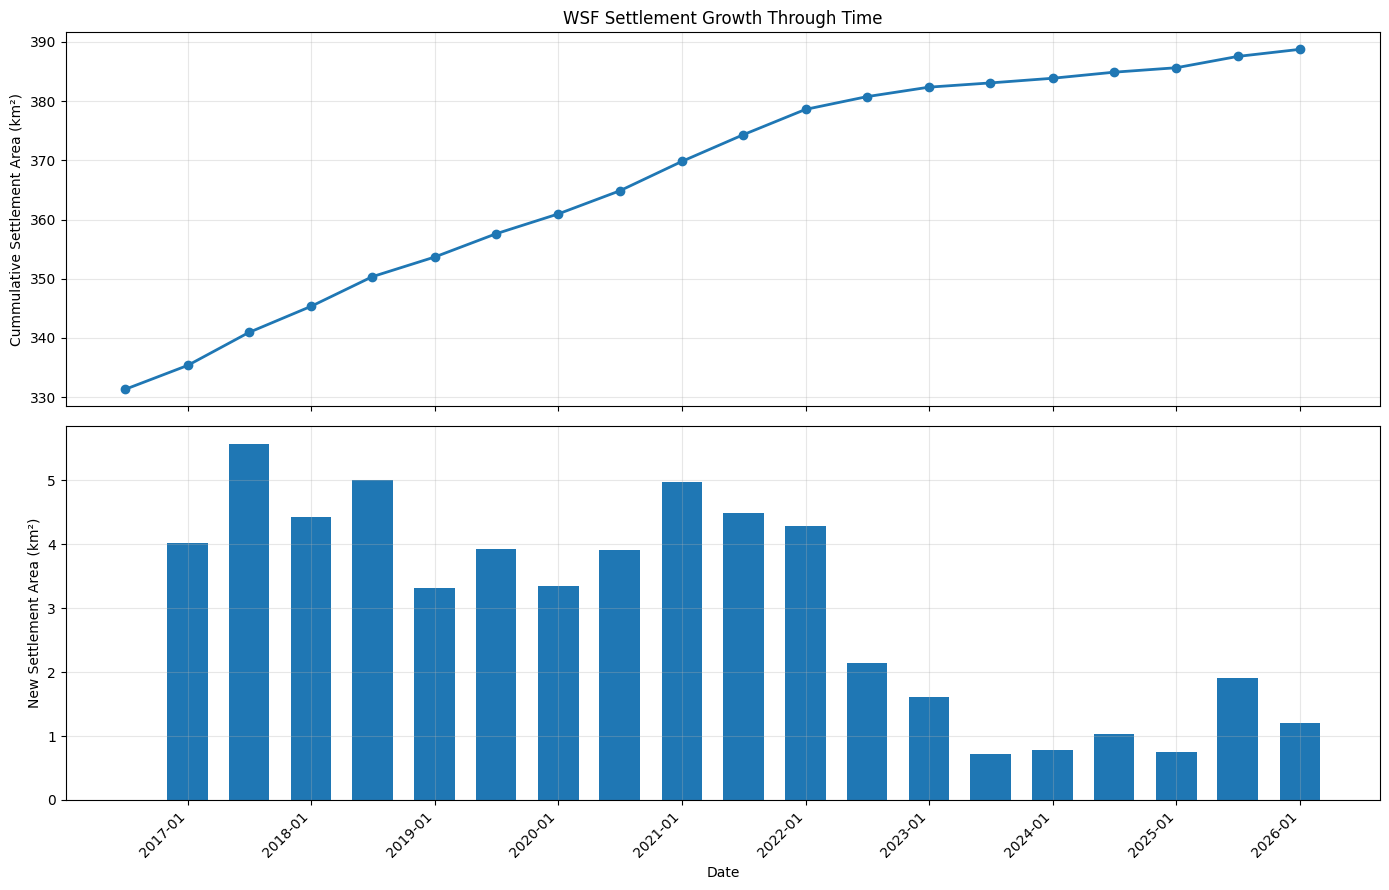

In [7]:
# Make sure date is datetime
df["date"] = pd.to_datetime(df["date"])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
# Cumulative settlement extent
ax1.plot(df["date"], df["cumulative_settlement_area_km2"], marker="o", linewidth=2)
ax1.set_ylabel("Cummulative Settlement Area (km²)")
ax1.set_title("WSF Settlement Growth Through Time")
ax1.grid(alpha=0.3)
# Exclude first epoch because it represents the baseline
df_change = df.iloc[1:]
ax2.bar(df_change["date"], df_change["new_settlement_area_km2_per_period"], width=120)
ax2.set_ylabel("New Settlement Area (km²)")
ax2.set_xlabel("Date")
ax2.grid(alpha=0.3)
# Format dates
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Compare settlement extent between the baseline and target dates

The following cell compares cumulative settlement extent at the baseline and target dates and identifies areas that became newly settled between the two periods.

In [8]:
# Select cumulative settlement date
baseline_date = "2016-07-01"
target_date = "2026-01-01"
wsf_baseline = wsf["cummulative_settlement_extent"].sel(time=baseline_date)
wsf_target = wsf["cummulative_settlement_extent"].sel(time=target_date)
with ProgressBar():
    wsf_baseline, wsf_target = dask.compute(wsf_baseline, wsf_target)
# Change between baseline and target
change = ((wsf_target == 1) & (wsf_baseline == 0))

[########################################] | 100% Completed | 52.16 s


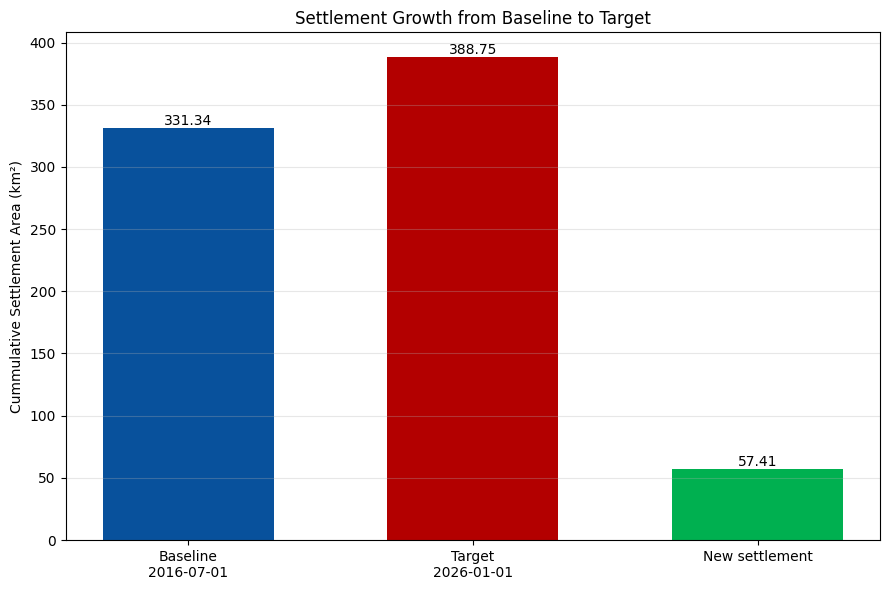

In [9]:
# Calculate total area for baseline, target, and change
# Approx. 10 m × 10 m pixel = 100 m² = 0.0001 km²
baseline_area = wsf_baseline.sum() * 0.0001
target_area = wsf_target.sum() * 0.0001
change_area = change.sum() * 0.0001
# Labels
labels = [f"Baseline\n{baseline_date}", f"Target\n{target_date}", "New settlement"]
values = [baseline_area, target_area, change_area]
colors = ["#08519c", "#b30000", "#00b050"]
# Plot
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(labels, values, color=colors, width=0.6)
ax.set_ylabel("Cummulative Settlement Area (km²)")
ax.set_title("Settlement Growth from Baseline to Target")
ax.grid(axis="y", alpha=0.3)
# Add values above bars
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,  bar.get_height(), f"{value:.2f}", ha="center",  va="bottom")
plt.tight_layout()
plt.show() 

### Map settlement change between the baseline and target dates

The maps below compare settlement extent at the baseline and target dates and highlight areas of new settlement growth that emerged between the two periods.

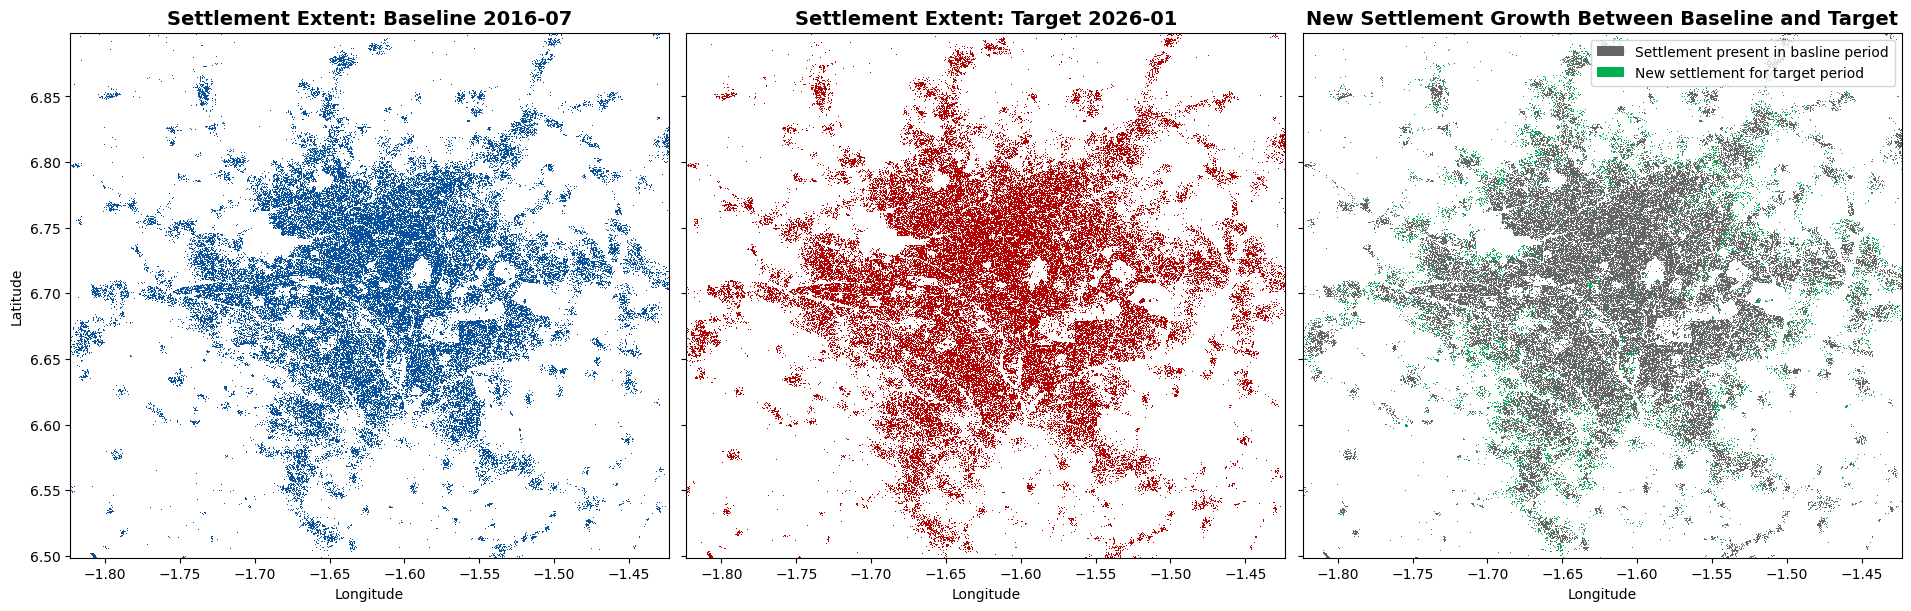

In [10]:
# Create combined change classes, 0 = nodata, 1 = settlement already present in 2017, 2 = new settlement added by 2024
comparison = xr.zeros_like(wsf_target, dtype="uint8")
comparison = comparison.where(wsf_baseline == 0, other=1)
comparison = comparison.where(~change, other=2)
# Colormaps
cmap_basline = ListedColormap(["white", "#08519c"])
cmap_target = ListedColormap(["white", "#b30000"])
cmap_change = ListedColormap(["white", "#666666", "#00b050"])
# Plot
fig, axes = plt.subplots(1, 3, figsize=(19, 6), sharey=True, constrained_layout=True)
# Baseline Plot
wsf_baseline.plot(ax=axes[0], cmap=cmap_basline, vmin=0, vmax=1, add_colorbar=False)
axes[0].set_title(f"Settlement Extent: Baseline {pd.Timestamp(baseline_date).strftime("%Y-%m")}", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
# Target Plot
wsf_target.plot(ax=axes[1], cmap=cmap_target, vmin=0, vmax=1, add_colorbar=False)
axes[1].set_title(f"Settlement Extent: Target {pd.Timestamp(target_date).strftime("%Y-%m")}", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("")
# Combined settlement-change map
comparison.plot(ax=axes[2], cmap=cmap_change, vmin=0, vmax=2, levels=[-0.5, 0.5, 1.5, 2.5], add_colorbar=False)
axes[2].set_title(f"New Settlement Growth Between Baseline and Target", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("")
# Legend for change map
legend_items = [Patch(facecolor="#666666", label="Settlement present in basline period"), Patch(facecolor="#00b050", label="New settlement for target period")]
axes[2].legend(handles=legend_items, loc="upper right", frameon=True)
plt.show()

### Conclusion

The World Settlement Footprint offers a knowledge base that can help researchers, governmental organizations, and other stakeholders, such as urban planners, better understand how urbanization is happening and, concurrently, put in place sustainable urban development strategies for informed policy decisions at local and national levels.


**Note**

To run for different area go to cell **Analysis parameters**, change the **lat** and **lon** values in the **define_area_function**.

---

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:**

In [11]:
print(datacube.__version__)

1.9.13


**Last tested:**

In [12]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-09-22'